In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
print("All modules imported successfully.")

All modules imported successfully.


Dataset Shape: (569, 30)
Target Distribution:
target
1    357
0    212
Name: count, dtype: int64


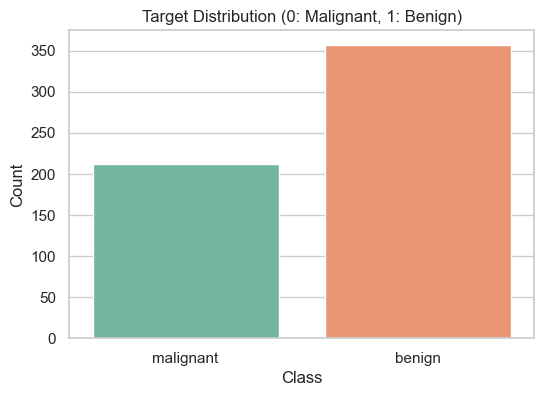

,mean,std,min,50%,max
mean radius,14.127292,3.524049,6.98100,13.37000,28.11000
mean texture,19.289649,4.301036,9.71000,18.84000,39.28000
mean perimeter,91.969033,24.298981,43.79000,86.24000,188.50000
mean area,654.889104,351.914129,143.50000,551.10000,2501.00000
mean smoothness,0.096360,0.014064,0.05263,0.09587,0.16340
mean compactness,0.104341,0.052813,0.01938,0.09263,0.34540
mean concavity,0.088799,0.079720,0.00000,0.06154,0.42680
mean concave points,0.048919,0.038803,0.00000,0.03350,0.20120
mean symmetry,0.181162,0.027414,0.10600,0.17920,0.30400
mean fractal dimension,0.062798,0.007060,0.04996,0.06154,0.09744


In [4]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target') # 0: Malignant, 1: Benign

print(f"Dataset Shape: {X.shape}")
print(f"Target Distribution:\n{y.value_counts()}")

plt.figure(figsize=(6, 4))
sns.countplot(x=y, hue=y, legend=False, palette='Set2')
plt.xticks(ticks=[0, 1], labels=data.target_names)
plt.title("Target Distribution (0: Malignant, 1: Benign)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

X.describe().T[['mean', 'std', 'min', '50%', 'max']].head(10)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 455
Testing set size: 114


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

bagging_param_grid = {
    'n_estimators': [10, 30, 50, 100],
    'max_samples': [0.5, 0.7, 1.0],
    'max_features': [0.5, 0.7, 1.0]
}

bagging_grid = GridSearchCV(
    estimator=BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE), random_state=RANDOM_STATE),
    param_grid=bagging_param_grid,
    cv=cv,
    scoring=['accuracy', 'f1'],
    refit='f1',
    n_jobs=-1
)
bagging_grid.fit(X_train_scaled, y_train)

adaboost_param_grid = {
    'n_estimators': [30, 50, 100],
    'learning_rate': [0.01, 0.1, 1.0]
}

adaboost_grid = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=RANDOM_STATE),
    param_grid=adaboost_param_grid,
    cv=cv,
    scoring=['accuracy', 'f1'],
    refit='f1',
    n_jobs=-1
)
adaboost_grid.fit(X_train_scaled, y_train)

gb_param_grid = {
    'n_estimators': [30, 50, 100],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=gb_param_grid,
    cv=cv,
    scoring=['accuracy', 'f1'],
    refit='f1',
    n_jobs=-1
)
gb_grid.fit(X_train_scaled, y_train)

base_learners = [
    ('svm', SVC(probability=True, random_state=RANDOM_STATE)),
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE))
]

stacking_param_grid = {
    'final_estimator__C': [0.01, 0.1, 1.0, 10.0]
}

stacking_grid = GridSearchCV(
    estimator=StackingClassifier(
        estimators=base_learners,
        final_estimator=LogisticRegression(random_state=RANDOM_STATE),
        cv=cv
    ),
    param_grid=stacking_param_grid,
    cv=cv,
    scoring=['accuracy', 'f1'],
    refit='f1',
    n_jobs=-1
)
stacking_grid.fit(X_train_scaled, y_train)

print("Hyperparameter Tuning Complete!")

Hyperparameter Tuning Complete!


In [7]:
bagging_results_df = pd.DataFrame(bagging_grid.cv_results_)
table1 = bagging_results_df[['param_n_estimators', 'param_max_samples', 'mean_test_accuracy', 'mean_test_f1']].copy()
table1.columns = ['n_estimators', 'max_samples', 'Avg CV Accuracy (%)', 'Avg CV F1 Score']
table1['Avg CV Accuracy (%)'] = (table1['Avg CV Accuracy (%)'] * 100).round(2)
table1['Avg CV F1 Score'] = table1['Avg CV F1 Score'].round(4)
print("--- TABLE 1: BAGGING HYPERPARAMETER EVALUATION ---")
print(table1.head(5).to_string(index=False))

gb_results_df = pd.DataFrame(gb_grid.cv_results_)
table2 = gb_results_df[['param_n_estimators', 'param_learning_rate', 'mean_test_accuracy', 'mean_test_f1']].copy()
table2.columns = ['n_estimators', 'learning_rate', 'Avg CV Accuracy (%)', 'Avg CV F1 Score']
table2['Avg CV Accuracy (%)'] = (table2['Avg CV Accuracy (%)'] * 100).round(2)
table2['Avg CV F1 Score'] = table2['Avg CV F1 Score'].round(4)
print("\n--- TABLE 2: BOOSTING HYPERPARAMETER EVALUATION (Gradient Boosting) ---")
print(table2.head(5).to_string(index=False))

table3 = pd.DataFrame([{
    'Base Models': 'SVM, Naive Bayes, Decision Tree',
    'Meta Learner': f"Logistic Regression (C={stacking_grid.best_params_['final_estimator__C']})",
    'Avg CV Accuracy (%)': round(stacking_grid.best_score_ * 100, 2),
    'Avg CV F1 Score': round(stacking_grid.cv_results_['mean_test_f1'][stacking_grid.best_index_], 4)
}])
print("\n--- TABLE 3: STACKED ENSEMBLE EVALUATION ---")
print(table3.to_string(index=False))

--- TABLE 1: BAGGING HYPERPARAMETER EVALUATION ---
 n_estimators  max_samples  Avg CV Accuracy (%)  Avg CV F1 Score
           10          0.5                95.16           0.9610
           30          0.5                96.04           0.9683
           50          0.5                96.04           0.9681
          100          0.5                95.38           0.9630
           10          0.7                94.95           0.9594

--- TABLE 2: BOOSTING HYPERPARAMETER EVALUATION (Gradient Boosting) ---
 n_estimators  learning_rate  Avg CV Accuracy (%)  Avg CV F1 Score
           30           0.01                92.97           0.9449
           50           0.01                93.41           0.9481
          100           0.01                93.85           0.9515
           30           0.01                93.85           0.9513
           50           0.01                93.19           0.9459

--- TABLE 3: STACKED ENSEMBLE EVALUATION ---
                    Base Models       

In [8]:
models = {
    'Bagging': bagging_grid.best_estimator_,
    'Boosting (AdaBoost)': adaboost_grid.best_estimator_,
    'Boosting (Gradient Boosting)': gb_grid.best_estimator_,
    'Stacked Ensemble': stacking_grid.best_estimator_
}

comparison_list = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred) * 100
    rec = recall_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred) * 100
    
    comparison_list.append({
        'Model': name,
        'Accuracy (%)': round(acc, 2),
        'Precision (%)': round(prec, 2),
        'Recall (%)': round(rec, 2),
        'F1 Score (%)': round(f1, 2)
    })

table4 = pd.DataFrame(comparison_list)
print("\n--- TABLE 4: PERFORMANCE COMPARISON OF ENSEMBLE MODELS ---")
print(table4.to_string(index=False))


--- TABLE 4: PERFORMANCE COMPARISON OF ENSEMBLE MODELS ---
                       Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
                     Bagging         94.74          95.83       95.83         95.83
         Boosting (AdaBoost)         95.61          94.67       98.61         96.60
Boosting (Gradient Boosting)         95.61          94.67       98.61         96.60
            Stacked Ensemble         97.37          98.59       97.22         97.90


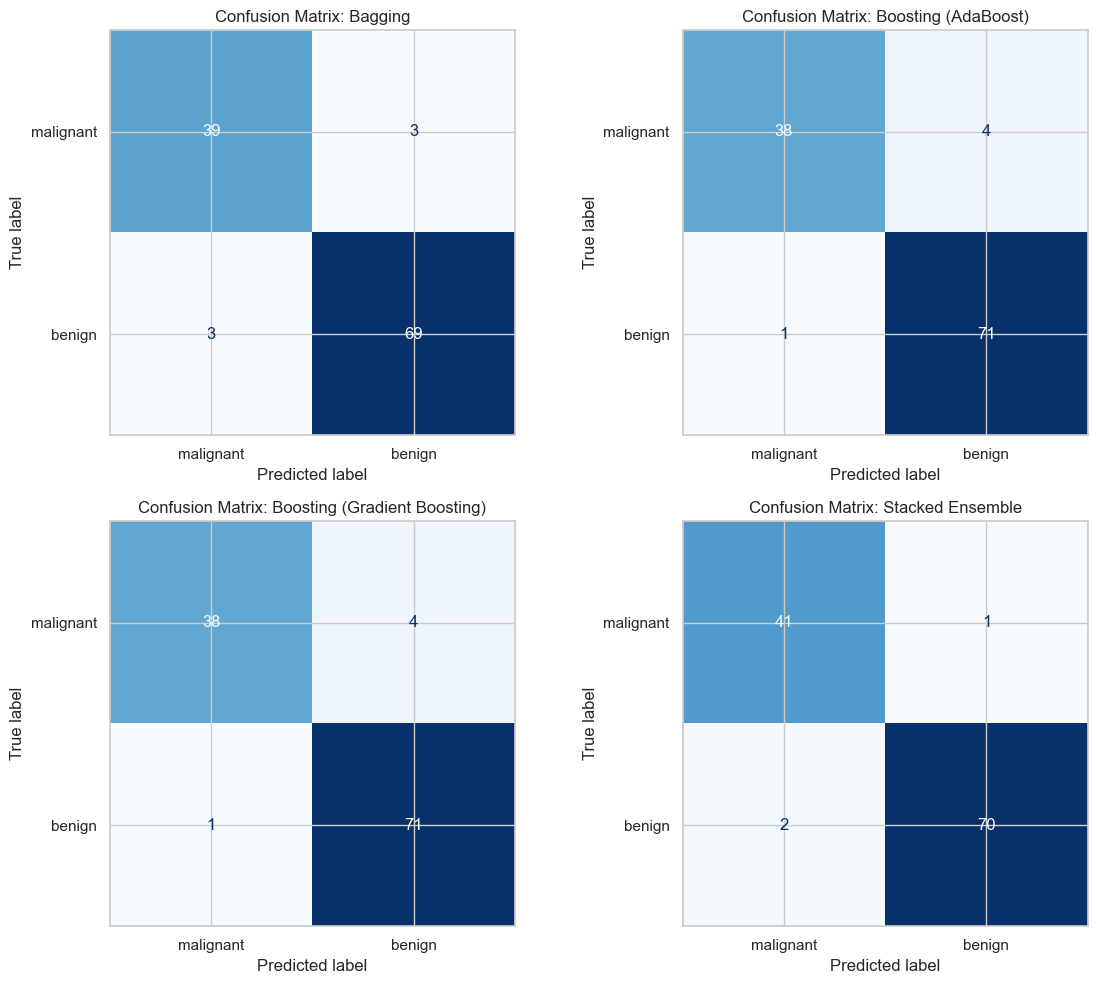

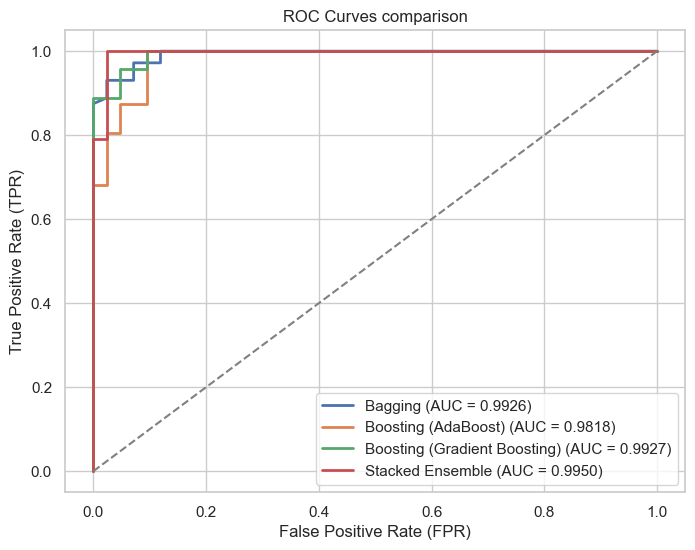

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f"Confusion Matrix: {name}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_probs = model.decision_function(X_test_scaled)
        
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curves comparison')
plt.legend(loc="lower right")
plt.show()